In [15]:
import os, random
import numpy as np
import pandas as pd
from glob import glob

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ==============================
# PATH DATASET
# ==============================
BASE_DIR = r"E:\DATASET"
DATA_DIR = r"E:\DATASET\TomatoDataset"

classes = [
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___healthy",
    "Tomato___Late_blight",
    "Tomato___Leaf_Mold",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Target_Spot",
    "Tomato___Tomato_mosaic_virus",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
]

In [16]:
# ==============================
# OUTPUT EDA
# ==============================
EDA_DIR = os.path.join(BASE_DIR, "eda_eksternal_output")
os.makedirs(EDA_DIR, exist_ok=True)

def list_images(folder):
    exts = ("*.jpg", "*.jpeg", "*.png",
            "*.JPG", "*.JPEG", "*.PNG")
    files = []
    for e in exts:
        files.extend(glob(os.path.join(folder, e)))
    return sorted(files)

class_counts = []

for cls in classes:
    cls_path = os.path.join(DATA_DIR, cls)

    print(cls_path, "| exist:", os.path.exists(cls_path))

    n = len(list_images(cls_path))

    class_counts.append({
        "Kelas": cls,
        "Jumlah Citra": n
    })

df_class = pd.DataFrame(class_counts)

print(df_class)
print("Total citra:", df_class["Jumlah Citra"].sum())

csv_path = os.path.join(EDA_DIR, "eda_class_distribution.csv")
df_class.to_csv(csv_path, index=False)

print("Saved:", csv_path)

E:\DATASET\TomatoDataset\Tomato___Bacterial_spot | exist: True
E:\DATASET\TomatoDataset\Tomato___Early_blight | exist: True
E:\DATASET\TomatoDataset\Tomato___healthy | exist: True
E:\DATASET\TomatoDataset\Tomato___Late_blight | exist: True
E:\DATASET\TomatoDataset\Tomato___Leaf_Mold | exist: True
E:\DATASET\TomatoDataset\Tomato___Septoria_leaf_spot | exist: True
E:\DATASET\TomatoDataset\Tomato___Spider_mites Two-spotted_spider_mite | exist: True
E:\DATASET\TomatoDataset\Tomato___Target_Spot | exist: True
E:\DATASET\TomatoDataset\Tomato___Tomato_mosaic_virus | exist: True
E:\DATASET\TomatoDataset\Tomato___Tomato_Yellow_Leaf_Curl_Virus | exist: True
                                           Kelas  Jumlah Citra
0                        Tomato___Bacterial_spot           216
1                          Tomato___Early_blight           596
2                               Tomato___healthy           314
3                           Tomato___Late_blight           222
4                            

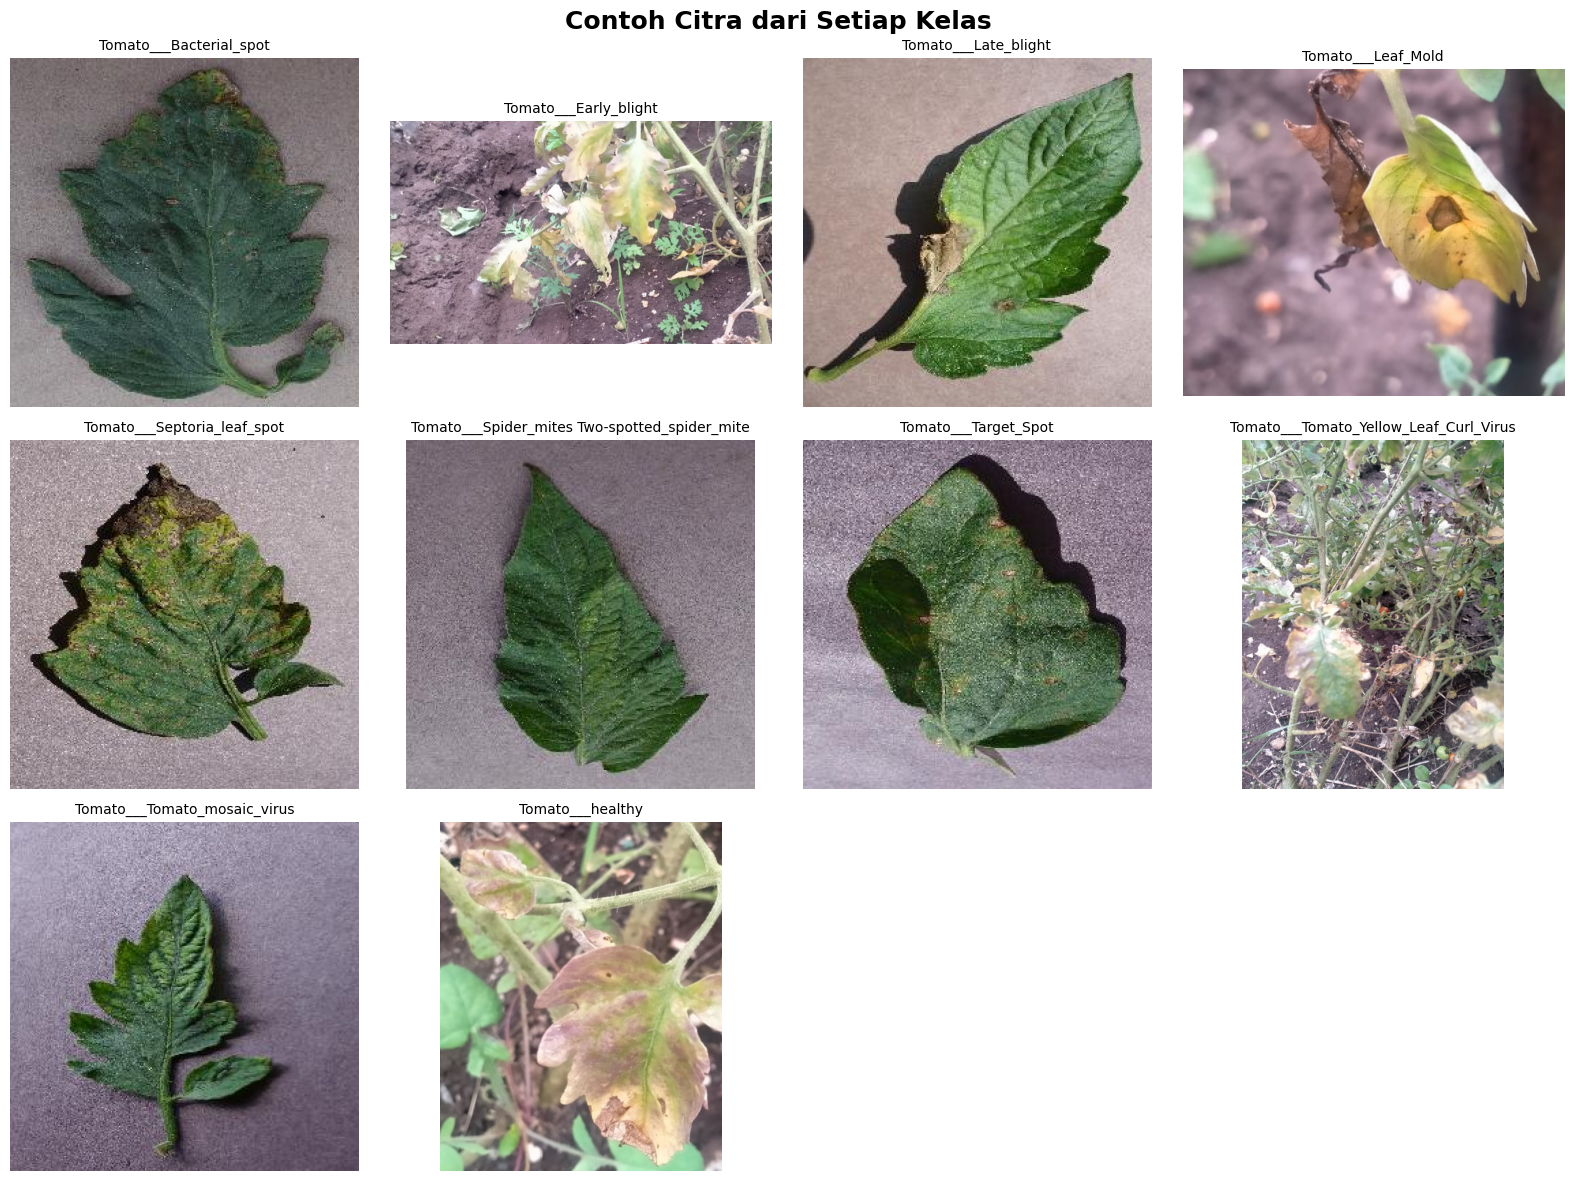

In [4]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image
# =========================================
# MENAMPILKAN 1 CONTOH GAMBAR PER KELAS
# =========================================
# =========================================
# PATH DATASET
# =========================================
DATASET_DIR = r"E:\DATASET\TomatoDataset"

# =========================================
# AMBIL 1 GAMBAR PER KELAS
# =========================================
sample_images = []

for class_name in sorted(os.listdir(DATASET_DIR)):

    class_path = os.path.join(DATASET_DIR, class_name)

    if os.path.isdir(class_path):

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        # Jika ada gambar
        if len(image_files) > 0:

            sample_path = os.path.join(
                class_path,
                image_files[0]
            )

            sample_images.append({
                "label": class_name,
                "path": sample_path
            })

# =========================================
# HITUNG GRID
# =========================================
num_classes = len(sample_images)

cols = 4
rows = math.ceil(num_classes / cols)

# =========================================
# VISUALISASI
# =========================================
plt.figure(figsize=(16, rows * 4))

for i, sample in enumerate(sample_images):

    img = Image.open(sample["path"])

    plt.subplot(rows, cols, i + 1)

    plt.imshow(img)

    plt.title(
        sample["label"],
        fontsize=10
    )

    plt.axis("off")

plt.suptitle(
    "Contoh Citra dari Setiap Kelas",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [17]:
sizes = []

for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in list_images(cls_dir):
        try:
            with Image.open(f) as img:
                w, h = img.size
            sizes.append({
                "Kelas": cls,
                "Width": w,
                "Height": h,
                "File": os.path.basename(f)
            })
        except:
            pass

df_sizes = pd.DataFrame(sizes)

display(df_sizes.head(10))
print("Total images recorded:", len(df_sizes))


,Kelas,Width,Height,File
0,Tomato___Bacterial_spot,256,256,01a3cf3f-94c1-44d5-8972-8c509d62558e___GCREC_B...
1,Tomato___Bacterial_spot,256,256,01a3cf3f-94c1-44d5-8972-8c509d62558e___GCREC_B...
2,Tomato___Bacterial_spot,256,256,01a46cb5-d354-4f59-868e-e56186701541___GCREC_B...
3,Tomato___Bacterial_spot,256,256,01a46cb5-d354-4f59-868e-e56186701541___GCREC_B...
4,Tomato___Bacterial_spot,256,256,01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_B...
5,Tomato___Bacterial_spot,256,256,01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_B...
6,Tomato___Bacterial_spot,256,256,01d9fc8d-5083-468d-a583-885f33517cdd___GCREC_B...
7,Tomato___Bacterial_spot,256,256,01d9fc8d-5083-468d-a583-885f33517cdd___GCREC_B...
8,Tomato___Bacterial_spot,256,256,01e079ba-939a-4681-8983-db663f4a859b___GCREC_B...
9,Tomato___Bacterial_spot,256,256,01e079ba-939a-4681-8983-db663f4a859b___GCREC_B...


Total images recorded: 3218


In [18]:
from collections import Counter

# Hitung frekuensi resolusi (width, height)
resolution_counter = Counter(
    [(row["Width"], row["Height"]) for _, row in df_sizes.iterrows()]
)

# Ambil Top 3 resolusi terbanyak
top3_res = resolution_counter.most_common(20)

# Buat tabel ringkas (Bab IV friendly)
top3_df = pd.DataFrame(
    top3_res,
    columns=["Resolusi (Width×Height)", "Jumlah Citra"]
)

# Pecah resolusi jadi width & height biar rapi
top3_df["Width"] = top3_df["Resolusi (Width×Height)"].apply(lambda x: x[0])
top3_df["Height"] = top3_df["Resolusi (Width×Height)"].apply(lambda x: x[1])

top3_df = top3_df[["Width", "Height", "Jumlah Citra"]]

display(top3_df)

# Simpan ke CSV (bukti Bab IV)
csv_top3 = os.path.join(EDA_DIR, "eda_top3_image_resolution.csv")
top3_df.to_csv(csv_top3, index=False)
print("Saved:", csv_top3)

,Width,Height,Jumlah Citra
0,256,256,1330
1,780,1040,712
2,3000,4000,194
3,4000,2250,130
4,1040,780,124
5,960,1280,124
6,3072,4096,96
7,3024,4032,96
8,720,1280,60
9,4000,3000,56


Saved: E:\DATASET\eda_eksternal_output\eda_top3_image_resolution.csv


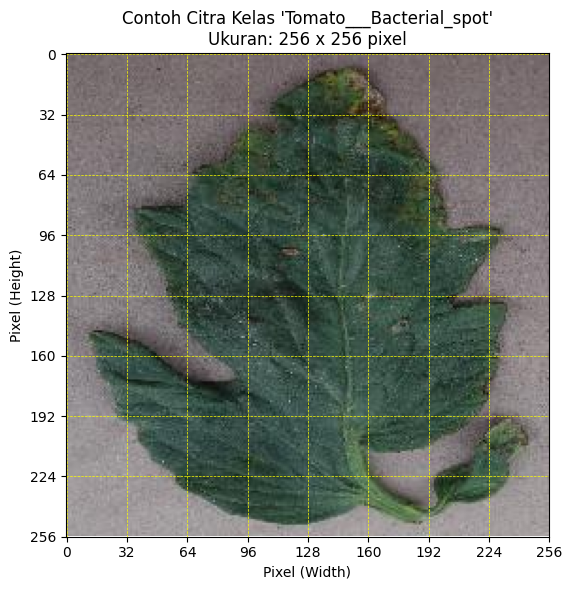

In [19]:
import matplotlib.pyplot as plt

# Ambil satu contoh gambar
sample_cls = classes[0]
sample_img_path = os.path.join(
    DATA_DIR, sample_cls,
    os.listdir(os.path.join(DATA_DIR, sample_cls))[0]
)

img = Image.open(sample_img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Contoh Citra Kelas '{sample_cls}'\nUkuran: {img.size[0]} x {img.size[1]} pixel")

# Aktifkan grid pixel
plt.xticks(np.linspace(0, img.size[0], 9))
plt.yticks(np.linspace(0, img.size[1], 9))
plt.grid(color="yellow", linestyle="--", linewidth=0.5)

plt.xlabel("Pixel (Width)")
plt.ylabel("Pixel (Height)")
plt.tight_layout()
plt.show()

In [20]:
broken = []
checked = 0

valid_ext = (".jpg",".jpeg",".png")

for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in os.listdir(cls_dir):
        if not f.lower().endswith(valid_ext):
            continue

        path = os.path.join(cls_dir, f)
        checked += 1
        try:
            with Image.open(path) as im:
                im.verify()  # cek struktur file
        except Exception as e:
            broken.append({
                "Kelas": cls,
                "File": f,
                "Path": path,
                "Error": str(e)[:150]
            })

broken_df = pd.DataFrame(broken)
broken_count = len(broken_df)

summary_df = pd.DataFrame([{
    "Total diperiksa": checked,
    "Valid": checked - broken_count,
    "Rusak / tidak terbuka": broken_count,
    "Persentase rusak (%)": round((broken_count/checked)*100, 4) if checked else 0
}])

print("=== RINGKASAN CEK GAMBAR RUSAK ===")
display(summary_df)

csv_summary = os.path.join(EDA_DIR, "eda_broken_summary.csv")
summary_df.to_csv(csv_summary, index=False)
print("Saved:", csv_summary)

if broken_count > 0:
    display(broken_df.head(10))
    csv_broken = os.path.join(EDA_DIR, "eda_broken_files.csv")
    broken_df.to_csv(csv_broken, index=False)
    print("Saved:", csv_broken)
else:
    print("✅ Tidak ditemukan gambar rusak.")


=== RINGKASAN CEK GAMBAR RUSAK ===


,Total diperiksa,Valid,Rusak / tidak terbuka,Persentase rusak (%)
0,1609,1609,0,0.0


Saved: E:\DATASET\eda_eksternal_output\eda_broken_summary.csv
✅ Tidak ditemukan gambar rusak.


In [21]:
# ======================================
# EDA: Cek Format Gambar (JPEG / PNG)
# ======================================

format_records = []

for cls in classes:
    cls_dir = os.path.join(DATA_DIR, cls)
    for f in list_images(cls_dir):
        ext = os.path.splitext(f)[1].lower()
        try:
            with Image.open(f) as img:
                detected_format = img.format
                width, height = img.size

            format_records.append({
                "Kelas": cls,
                "File": os.path.basename(f),
                "Extension": ext,
                "Detected_Format": detected_format,
                "Width": width,
                "Height": height,
                "Status": "OK"
            })

        except Exception as e:
            format_records.append({
                "Kelas": cls,
                "File": os.path.basename(f),
                "Extension": ext,
                "Detected_Format": "ERROR",
                "Width": None,
                "Height": None,
                "Status": str(e)[:150]
            })

df_format = pd.DataFrame(format_records)

print("Total citra diperiksa:", len(df_format))
display(df_format.head(10))


Total citra diperiksa: 3218


,Kelas,File,Extension,Detected_Format,Width,Height,Status
0,Tomato___Bacterial_spot,01a3cf3f-94c1-44d5-8972-8c509d62558e___GCREC_B...,.jpg,JPEG,256,256,OK
1,Tomato___Bacterial_spot,01a3cf3f-94c1-44d5-8972-8c509d62558e___GCREC_B...,.jpg,JPEG,256,256,OK
2,Tomato___Bacterial_spot,01a46cb5-d354-4f59-868e-e56186701541___GCREC_B...,.jpg,JPEG,256,256,OK
3,Tomato___Bacterial_spot,01a46cb5-d354-4f59-868e-e56186701541___GCREC_B...,.jpg,JPEG,256,256,OK
4,Tomato___Bacterial_spot,01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_B...,.jpg,JPEG,256,256,OK
5,Tomato___Bacterial_spot,01d7f4fe-793f-4a9b-bc8b-8aa05200984f___GCREC_B...,.jpg,JPEG,256,256,OK
6,Tomato___Bacterial_spot,01d9fc8d-5083-468d-a583-885f33517cdd___GCREC_B...,.jpg,JPEG,256,256,OK
7,Tomato___Bacterial_spot,01d9fc8d-5083-468d-a583-885f33517cdd___GCREC_B...,.jpg,JPEG,256,256,OK
8,Tomato___Bacterial_spot,01e079ba-939a-4681-8983-db663f4a859b___GCREC_B...,.jpg,JPEG,256,256,OK
9,Tomato___Bacterial_spot,01e079ba-939a-4681-8983-db663f4a859b___GCREC_B...,.jpg,JPEG,256,256,OK


In [22]:
# ======================================
# Ringkasan format gambar
# ======================================

format_summary = (
    df_format[df_format["Status"] == "OK"]
    .groupby(["Detected_Format", "Extension"])
    .size()
    .reset_index(name="Jumlah Citra")
)

print("=== RINGKASAN FORMAT GAMBAR ===")
display(format_summary)


=== RINGKASAN FORMAT GAMBAR ===


,Detected_Format,Extension,Jumlah Citra
0,JPEG,.jpg,3218



Distribusi Dataset:


,Kelas,Jumlah Citra
0,Tomato___Bacterial_spot,216
1,Tomato___Early_blight,596
2,Tomato___healthy,314
3,Tomato___Late_blight,222
4,Tomato___Leaf_Mold,800
5,Tomato___Septoria_leaf_spot,212
6,Tomato___Spider_mites Two-spotted_spider_mite,242
7,Tomato___Target_Spot,198
8,Tomato___Tomato_mosaic_virus,218
9,Tomato___Tomato_Yellow_Leaf_Curl_Virus,200



Total citra : 3218


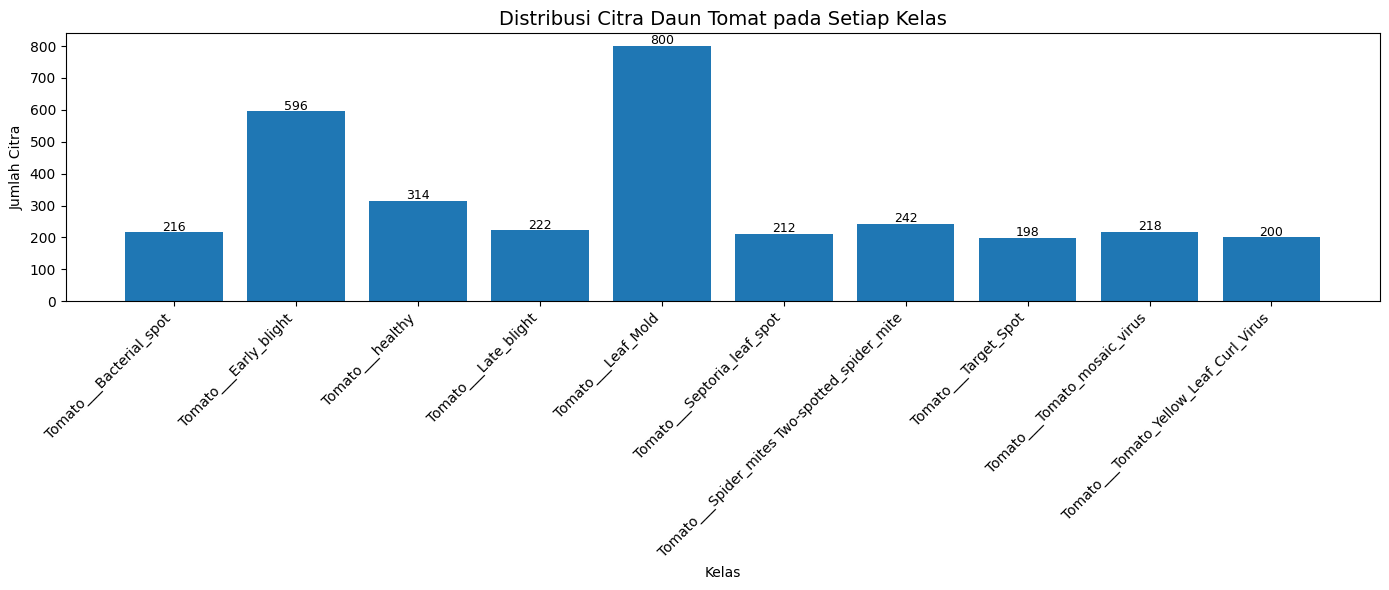

In [23]:
# =========================================
# DATAFRAME
# =========================================
df_class = pd.DataFrame(class_counts)

print("\nDistribusi Dataset:")
display(df_class)

print("\nTotal citra :", df_class["Jumlah Citra"].sum())

# =========================================
# VISUALISASI DISTRIBUSI
# =========================================
plt.figure(figsize=(14,6))

bars = plt.bar(
    df_class["Kelas"],
    df_class["Jumlah Citra"]
)

# tampilkan angka di atas bar
for bar in bars:
    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 5,
        int(yval),
        ha='center',
        fontsize=9
    )

plt.title("Distribusi Citra Daun Tomat pada Setiap Kelas", fontsize=14)
plt.xlabel("Kelas")
plt.ylabel("Jumlah Citra")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()